In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_PATH = Path("../data/raw/train.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(2930, 82)

In [3]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

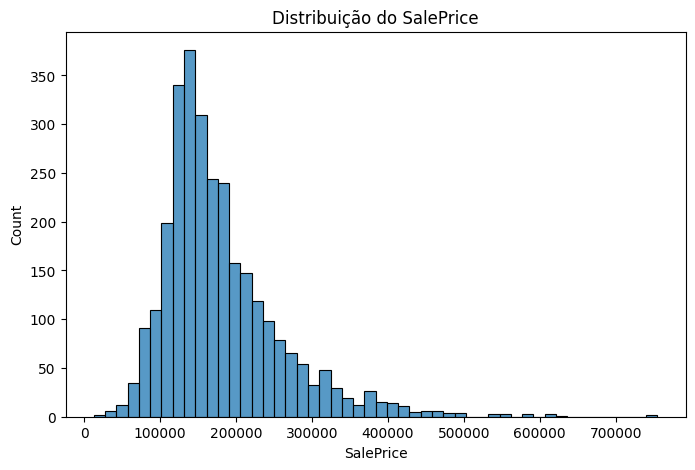

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=50)
plt.title("Distribuição do SalePrice")
plt.show()

In [5]:
df["SalePrice"].skew()

np.float64(1.7435000757376466)

In [6]:
df["LogSalePrice"] = np.log1p(df["SalePrice"])

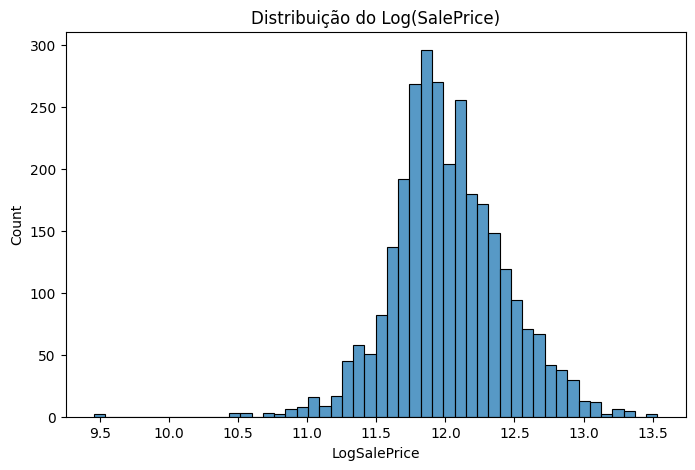

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["LogSalePrice"], bins=50)
plt.title("Distribuição do Log(SalePrice)")
plt.show()

In [8]:
df["LogSalePrice"].skew()

np.float64(-0.014772659537224368)

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

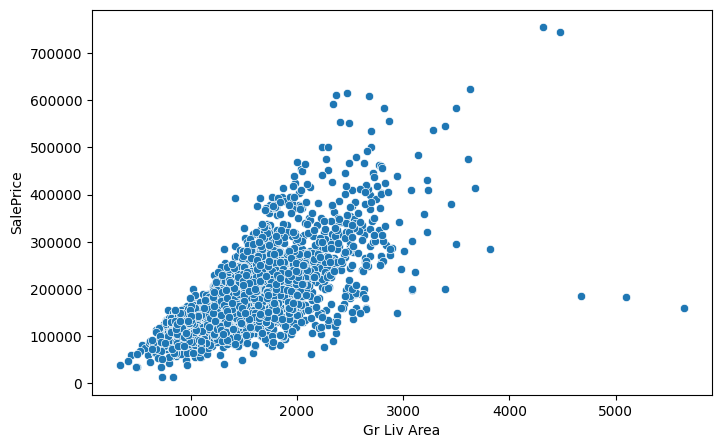

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Gr Liv Area"], y=df["SalePrice"])
plt.show()

In [3]:
import sys
from pathlib import Path

# adicionar raiz do projeto ao path
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [4]:
import numpy as np
import pandas as pd
import joblib
import shap

from sklearn.model_selection import train_test_split

from src.data import load_raw_data, handle_structural_missing, add_features, make_xy

c:\Users\marco\OneDrive\Desktop\Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = load_raw_data()
df = handle_structural_missing(df)
df = add_features(df)

X, y = make_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
xgb_pipe = joblib.load("../models/xgb_final.pkl")

In [8]:
preprocessor = xgb_pipe.named_steps["prep"]
model = xgb_pipe.named_steps["model"]

In [9]:
X_test_transformed = preprocessor.transform(X_test)

# se vier sparse matrix, converter
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

In [10]:
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

In [11]:
feature_names = xgb_pipe[:-1].get_feature_names_out()

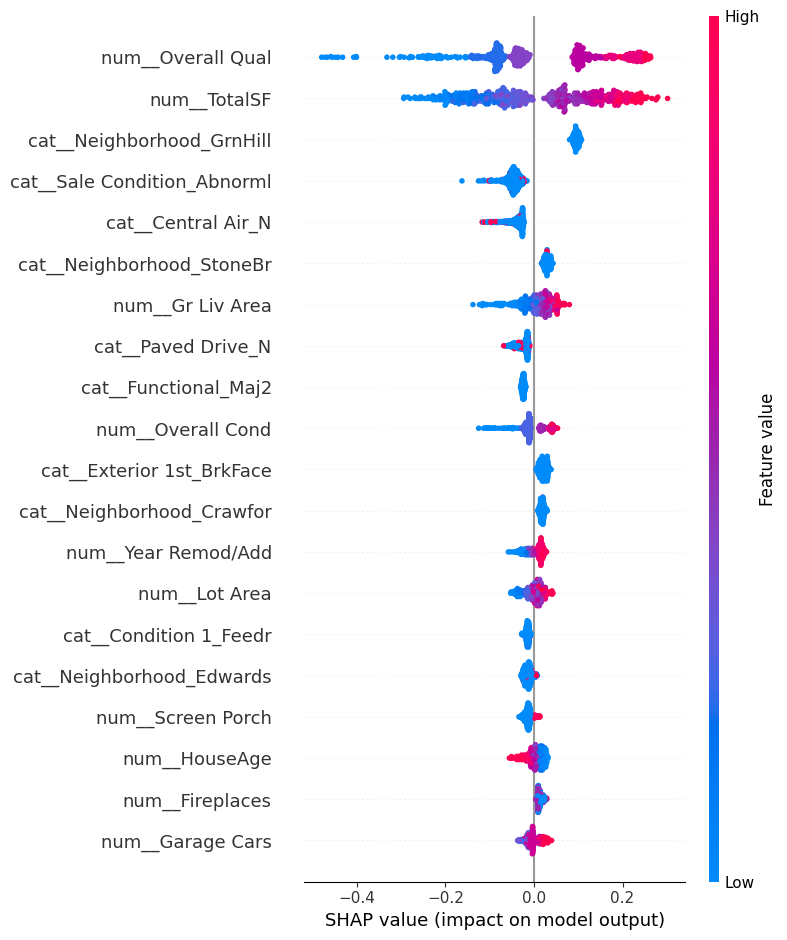

In [12]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)